# Module 5

## Pandas

This lecture provides an introduction to Pandas, a Python package with structures and data manipulation tools designed to make data cleaning and analysis fast and convenient. Topics include:

- Pandas objects (`pd.Series`, `pd.DataFrame`)
- Essential pandas functionality (indexing, selection, filtering, operations on dataframes)
- The concept of tidy data (Wickham, 2014)

## About Pandas 

Pandas is the Python module that provides functionality similar to R's built-in data.frame object. Pandas is designed for working with tabular or heterogeneous data. 

In [557]:
# Import packages
import numpy as np
import pandas as pd
import seaborn as sns

# CHeck pandas version
# It has changed substantially in the last few years
pd.__version__

'3.0.1'

### Pandas Series

A Series is a one-dimensional array-like object containing a sequence of values (of similar types to NumPy types) of the same type and an associated array of data labels, called its index. 

In [558]:
s = pd.Series([2, 4, -1, 5])
s

0    2
1    4
2   -1
3    5
dtype: int64

In [559]:
s.array

<NumpyExtensionArray>
[2, 4, -1, 5]
Length: 4, dtype: int64

In [560]:
s.index

RangeIndex(start=0, stop=4, step=1)

In [561]:
s = pd.Series([2, 4, -1, 5], index=['a', 'b', 'c', 'd'])

In [562]:
s.index

Index(['a', 'b', 'c', 'd'], dtype='str')

In [563]:
s['a']

np.int64(2)

In [564]:
s[['a', 'd']]

a    2
d    5
dtype: int64

In [565]:
s[s>2]

b    4
d    5
dtype: int64

We can create a series from a numpy array:

In [566]:
# Creating a numpy array
a = np.arange(6, 15, 1) + 0.2
print(a.shape)
a

(9,)


array([ 6.2,  7.2,  8.2,  9.2, 10.2, 11.2, 12.2, 13.2, 14.2])

In [567]:
s_from_np = pd.Series(a)
s_from_np

0     6.2
1     7.2
2     8.2
3     9.2
4    10.2
5    11.2
6    12.2
7    13.2
8    14.2
dtype: float64

In [568]:
s_from_np.array

<NumpyExtensionArray>
[6.2, 7.2, 8.2, 9.2, 10.2, 11.2, 12.2, 13.2, 14.2]
Length: 9, dtype: float64

In [569]:
s_from_np.index

RangeIndex(start=0, stop=9, step=1)

We can adjust the index in place:

Finally, we can turn the Series object back to an ndarray as:

In [570]:
s_from_np.to_numpy()

array([ 6.2,  7.2,  8.2,  9.2, 10.2, 11.2, 12.2, 13.2, 14.2])

We can also create a series from a dictionary:

In [571]:
dat = {"Ohio": 3500, "Texas": 7100, "Oregon": 1600, "Utah": 5000}
s_from_dict = pd.Series(dat)
s_from_dict

Ohio      3500
Texas     7100
Oregon    1600
Utah      5000
dtype: int64

### Pandas DataFrame

A DataFrame represents a rectangular table of data and contains an ordered, named collection of columns, each of which can be a different value type (numeric, string, Boolean, etc.). The DataFrame has both a row and column index; it can be thought of as a dictionary of Series all sharing the same index.

In [572]:
data = {"state": ["Ohio", "Ohio", "Ohio", "Nevada", "Nevada", "Nevada"],
"year": [2000, 2001, 2002, 2001, 2002, 2003],
"pop": [1.5, 1.7, 3.6, 2.4, 2.9, 3.2]}
frame = pd.DataFrame(data)

In [573]:
frame

,state,year,pop
0,Ohio,2000,1.5
1,Ohio,2001,1.7
2,Ohio,2002,3.6
3,Nevada,2001,2.4
4,Nevada,2002,2.9
5,Nevada,2003,3.2


In [574]:
# adding a column (similar to dictionaries)
frame['debt'] = 16

In [575]:
frame

,state,year,pop,debt
0,Ohio,2000,1.5,16
1,Ohio,2001,1.7,16
2,Ohio,2002,3.6,16
3,Nevada,2001,2.4,16
4,Nevada,2002,2.9,16
5,Nevada,2003,3.2,16


In [576]:
len(frame)

6

In [577]:
frame['debt'] = np.linspace(16,20,num=len(frame))
frame

,state,year,pop,debt
0,Ohio,2000,1.5,16.0
1,Ohio,2001,1.7,16.8
2,Ohio,2002,3.6,17.6
3,Nevada,2001,2.4,18.4
4,Nevada,2002,2.9,19.2
5,Nevada,2003,3.2,20.0


In [578]:
# another example
rng = np.random.default_rng(seed=0)
A2d = rng.standard_normal(size=(8, 2))
A2d.shape

(8, 2)

In [579]:
df_from_np = pd.DataFrame(A2d)
df_from_np

,0,1
0,0.125730,-0.132105
1,0.640423,0.104900
2,-0.535669,0.361595
3,1.304000,0.947081
4,-0.703735,-1.265421
5,-0.623274,0.041326
6,-2.325031,-0.218792
7,-1.245911,-0.732267


In [580]:
df_from_np.head()

,0,1
0,0.125730,-0.132105
1,0.640423,0.104900
2,-0.535669,0.361595
3,1.304000,0.947081
4,-0.703735,-1.265421


In [581]:
df_from_np.tail()

,0,1
3,1.304000,0.947081
4,-0.703735,-1.265421
5,-0.623274,0.041326
6,-2.325031,-0.218792
7,-1.245911,-0.732267


In [582]:
df_from_np.to_numpy()

array([[ 0.12573022, -0.13210486],
       [ 0.64042265,  0.10490012],
       [-0.53566937,  0.36159505],
       [ 1.30400005,  0.94708096],
       [-0.70373524, -1.26542147],
       [-0.62327446,  0.04132598],
       [-2.32503077, -0.21879166],
       [-1.24591095, -0.73226735]])

#### Indices

In [583]:
df_from_np.index

RangeIndex(start=0, stop=8, step=1)

In [584]:
indices = list('abcdefgh')
indices

['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']

In [585]:
df_from_np = pd.DataFrame(A2d, index=indices)
df_from_np

,0,1
a,0.125730,-0.132105
b,0.640423,0.104900
c,-0.535669,0.361595
d,1.304000,0.947081
e,-0.703735,-1.265421
f,-0.623274,0.041326
g,-2.325031,-0.218792
h,-1.245911,-0.732267


In [586]:
type(df_from_np.index)

pandas.Index

In [587]:
obj = pd.Series([4.5, 7.2,-5.3, 3.6], index=["d", "b", "a", "c"])

In [588]:
obj.reindex(['a', 'b', 'c', 'd', 'e'])

a   -5.3
b    7.2
c    3.6
d    4.5
e    NaN
dtype: float64

In [589]:
obj2 = obj.reindex(['a', 'a', 'b', 'c', 'd'])

In [590]:
obj2.index.is_unique

False

In [591]:
obj2['a']

a   -5.3
a   -5.3
dtype: float64

#### Columns

In [592]:
df_from_np.columns

RangeIndex(start=0, stop=2, step=1)

In [593]:
df_from_np.columns = ['firstCol', 'secondCol']
df_from_np

,firstCol,secondCol
a,0.125730,-0.132105
b,0.640423,0.104900
c,-0.535669,0.361595
d,1.304000,0.947081
e,-0.703735,-1.265421
f,-0.623274,0.041326
g,-2.325031,-0.218792
h,-1.245911,-0.732267


#### Datatypes

In [594]:
df_from_np.dtypes

firstCol     float64
secondCol    float64
dtype: object

## Illustration: Diffusion MRI data

### Reading in csv files

First, make sure the file is in your **working directory** - this is 'where you are currently' on the computer.

Python needs to know where the files live - they can be on your computer (local) or on the internet (remote).

The place where your file lives is referred to as its 'path'. You can think of the path as directions to the file. There are two kinds of paths: 

- *relative* paths indicate where a file is with respect to your working directory
- *absolute* paths indicate where the file is with respect to the computers filesystem base (or root) folder, regardless of where you are working

Image from *Data Science: A first introduction with Python* [(link)](https://python.datasciencebook.ca/index.html)


<img src="https://python.datasciencebook.ca/_images/filesystem.png" width="400" height="500" />


In VSCode, your working directory is typically where your Jupyter notebook is saved.

In [595]:
import os
os.getcwd()

'/home/eardi/git/BIOST506'

We will be working with the [Weston Havens dataset](https://tractometry.org/AFQ-Insight/auto_examples/plot_age_regression.html), preprocessed using pyAFQ (see Figure below). The preprocessed data consist of following variables:
- subjectID: a unique identifier for each subject
- tractID: a unique identifier for each brain pathway
- nodeID: a unique identifier for each position along the pathway, from 0 to 99
- fa, md, ...: diffusion MRI measurements describing the structural properties of the brain pathway at that specific location



<img src="https://tractometry.org/pyAFQ/_images/sphx_glr_plot_005_viz_002.png" width="300" height="300" />

Here, we retrieve data from an online server. Pandas makes this easy by allowing us to use a URL instead of a local file path (relative or absolute).

In [596]:
df = pd.read_csv('https://github.com/tractometry/AFQ-Insight/blob/main/afqinsight/data/classification_data/nodes.csv?raw=true')

Let's look at the dataframe.

In [597]:
df.head()  
df.tractID.unique()

<StringArray>
[   'Left Thalamic Radiation',   'Right Thalamic Radiation',
         'Left Corticospinal',        'Right Corticospinal',
    'Left Cingulum Cingulate',   'Right Cingulum Cingulate',
  'Left Cingulum Hippocampus', 'Right Cingulum Hippocampus',
     'Callosum Forceps Major',     'Callosum Forceps Minor',
                  'Left IFOF',                 'Right IFOF',
                   'Left ILF',                  'Right ILF',
                   'Left SLF',                  'Right SLF',
              'Left Uncinate',             'Right Uncinate',
               'Left Arcuate',              'Right Arcuate']
Length: 20, dtype: str

In [598]:
df.tail()

,subjectID,tractID,nodeID,volume,md,ad,cl,curvature,rd,fa,torsion
95995,subject_047,Right Arcuate,95,107.0,0.774928,1.040073,0.152306,0.061557,0.642356,0.292326,0.000511
95996,subject_047,Right Arcuate,96,107.0,0.758139,1.014998,0.148630,0.065756,0.629709,0.291324,0.432318
95997,subject_047,Right Arcuate,97,127.0,0.743737,0.969239,0.128892,0.086247,0.630986,0.265358,0.243808
95998,subject_047,Right Arcuate,98,118.0,0.748466,0.937630,0.103746,0.073557,0.653884,0.225859,0.191906
95999,subject_047,Right Arcuate,99,130.0,0.769562,0.922073,0.077380,0.051490,0.693306,0.182152,0.171146


In [599]:
df.shape

(96000, 11)

Create row index

In [600]:
df.index = df['subjectID']

We can inspect the data types of each column:

In [601]:
df.dtypes

subjectID        str
tractID          str
nodeID         int64
volume       float64
md           float64
ad           float64
cl           float64
curvature    float64
rd           float64
fa           float64
torsion      float64
dtype: object

### Accessing a column

In [602]:
df['fa']

subjectID
subject_000    0.174314
subject_000    0.227283
subject_000    0.281729
subject_000    0.317533
subject_000    0.340960
                 ...   
subject_047    0.292326
subject_047    0.291324
subject_047    0.265358
subject_047    0.225859
subject_047    0.182152
Name: fa, Length: 96000, dtype: float64

In [603]:
type(df['fa'])

pandas.Series

In [604]:
df.fa

subjectID
subject_000    0.174314
subject_000    0.227283
subject_000    0.281729
subject_000    0.317533
subject_000    0.340960
                 ...   
subject_047    0.292326
subject_047    0.291324
subject_047    0.265358
subject_047    0.225859
subject_047    0.182152
Name: fa, Length: 96000, dtype: float64

### Selecting/dropping multiple columns or rows

In [605]:
# Subsets of columns
df[['tractID', 'nodeID','fa']]

,tractID,nodeID,fa
subjectID,,,
subject_000,Left Thalamic Radiation,0,0.174314
subject_000,Left Thalamic Radiation,1,0.227283
subject_000,Left Thalamic Radiation,2,0.281729
subject_000,Left Thalamic Radiation,3,0.317533
subject_000,Left Thalamic Radiation,4,0.340960
...,...,...,...
subject_047,Right Arcuate,95,0.292326
subject_047,Right Arcuate,96,0.291324
subject_047,Right Arcuate,97,0.265358


In [606]:
df[['tractID', 'fa']].head()

,tractID,fa
subjectID,,
subject_000,Left Thalamic Radiation,0.174314
subject_000,Left Thalamic Radiation,0.227283
subject_000,Left Thalamic Radiation,0.281729
subject_000,Left Thalamic Radiation,0.317533
subject_000,Left Thalamic Radiation,0.340960


In [607]:
df
df_dropped = df.drop(columns=['cl', 'curvature', 'rd', 'torsion'])
df_dropped.head()

,subjectID,tractID,nodeID,volume,md,ad,fa
subjectID,,,,,,,
subject_000,subject_000,Left Thalamic Radiation,0,88.0,0.964562,1.137844,0.174314
subject_000,subject_000,Left Thalamic Radiation,1,78.0,0.912117,1.139359,0.227283
subject_000,subject_000,Left Thalamic Radiation,2,71.0,0.873796,1.155854,0.281729
subject_000,subject_000,Left Thalamic Radiation,3,78.0,0.851179,1.167977,0.317533
subject_000,subject_000,Left Thalamic Radiation,4,84.0,0.830402,1.164658,0.340960


In [608]:
df.head() # original df unaffected

,subjectID,tractID,nodeID,volume,md,ad,cl,curvature,rd,fa,torsion
subjectID,,,,,,,,,,,
subject_000,subject_000,Left Thalamic Radiation,0,88.0,0.964562,1.137844,0.066332,0.052703,0.877920,0.174314,-0.123092
subject_000,subject_000,Left Thalamic Radiation,1,78.0,0.912117,1.139359,0.101223,0.070959,0.798496,0.227283,-0.125926
subject_000,subject_000,Left Thalamic Radiation,2,71.0,0.873796,1.155854,0.139827,0.076268,0.732766,0.281729,-0.350745
subject_000,subject_000,Left Thalamic Radiation,3,78.0,0.851179,1.167977,0.166216,0.065503,0.692781,0.317533,-0.394558
subject_000,subject_000,Left Thalamic Radiation,4,84.0,0.830402,1.164658,0.182578,0.074702,0.663274,0.340960,-0.019610


In [609]:
# dropping rows
df_dropped.drop('subject_000').head()
# same as: df_dropped.drop(index=127).head()

,subjectID,tractID,nodeID,volume,md,ad,fa
subjectID,,,,,,,
subject_001,subject_001,Left Thalamic Radiation,0,15.0,1.179676,1.430010,0.196039
subject_001,subject_001,Left Thalamic Radiation,1,15.0,1.192818,1.468373,0.215188
subject_001,subject_001,Left Thalamic Radiation,2,14.0,1.207549,1.502617,0.233000
subject_001,subject_001,Left Thalamic Radiation,3,20.0,1.201679,1.527298,0.260264
subject_001,subject_001,Left Thalamic Radiation,4,18.0,1.188244,1.549110,0.290479


### Selecting rows

#### Series

**Note**: be careful with accessing data - it will treat integers as labels

In [610]:
fa = df['fa'].copy()
fa.index = df['subjectID'].str.split('_').str[1].astype(int)
fa.head()

subjectID
0    0.174314
0    0.227283
0    0.281729
0    0.317533
0    0.340960
Name: fa, dtype: float64

In [611]:
# This is a Series, not a DataFrame
# I discourage using this, use .loc or .iloc instead

fa[2]

subjectID
2         NaN
2    0.230596
2    0.276045
2    0.321541
2    0.351009
       ...   
2         NaN
2         NaN
2         NaN
2         NaN
2         NaN
Name: fa, Length: 2000, dtype: float64

To avoid this, use the `.loc` method for labels, and `.iloc` for integers. 

In [612]:
fa.loc[2]

subjectID
2         NaN
2    0.230596
2    0.276045
2    0.321541
2    0.351009
       ...   
2         NaN
2         NaN
2         NaN
2         NaN
2         NaN
Name: fa, Length: 2000, dtype: float64

In [613]:
fa.iloc[2]

np.float64(0.281729331925)

#### Dataframes

In [614]:
print(df.loc['subject_001'].head())
print(type(df.loc['subject_001']))

               subjectID                  tractID  nodeID  volume        md  \
subjectID                                                                     
subject_001  subject_001  Left Thalamic Radiation       0    15.0  1.179676   
subject_001  subject_001  Left Thalamic Radiation       1    15.0  1.192818   
subject_001  subject_001  Left Thalamic Radiation       2    14.0  1.207549   
subject_001  subject_001  Left Thalamic Radiation       3    20.0  1.201679   
subject_001  subject_001  Left Thalamic Radiation       4    18.0  1.188244   

                   ad        cl  curvature        rd        fa   torsion  
subjectID                                                                 
subject_001  1.430010  0.085243   0.054419  1.054509  0.196039  0.465605  
subject_001  1.468373  0.090712   0.084960  1.055041  0.215188  0.201579  
subject_001  1.502617  0.089345   0.108862  1.060014  0.233000  0.239277  
subject_001  1.527298  0.101670   0.085776  1.038870  0.260264 -0.06049

In [615]:
df.loc['subject_001', ['nodeID', 'fa']]

,nodeID,fa
subjectID,,
subject_001,0,0.196039
subject_001,1,0.215188
subject_001,2,0.233000
subject_001,3,0.260264
subject_001,4,0.290479
...,...,...
subject_001,95,0.273067
subject_001,96,0.257954
subject_001,97,0.254548


#### iloc

In [616]:
print(df.iloc[0])
print(type(df.iloc[0]))

subjectID                subject_000
tractID      Left Thalamic Radiation
nodeID                             0
volume                          88.0
md                          0.964562
ad                          1.137844
cl                          0.066332
curvature                   0.052703
rd                           0.87792
fa                          0.174314
torsion                    -0.123092
Name: subject_000, dtype: object
<class 'pandas.Series'>


In [617]:
df.iloc[:10, 1:4] # select a few rows, only keep columns 1,2,3

,tractID,nodeID,volume
subjectID,,,
subject_000,Left Thalamic Radiation,0,88.0
subject_000,Left Thalamic Radiation,1,78.0
subject_000,Left Thalamic Radiation,2,71.0
subject_000,Left Thalamic Radiation,3,78.0
subject_000,Left Thalamic Radiation,4,84.0
subject_000,Left Thalamic Radiation,5,79.0
subject_000,Left Thalamic Radiation,6,98.0
subject_000,Left Thalamic Radiation,7,91.0
subject_000,Left Thalamic Radiation,8,94.0


|Type |  Notes |
|-----|--------|
|`df[column]` |Select single column or sequence of columns from the DataFrame; special case conveniences: Boolean array (filter rows), slice (slice rows), or Boolean DataFrame (set values based on some criterion)|
|  `df.loc[rows]`| Select single row or subset of rows from the DataFrame by label|
|  `df.loc[:,cols]`|  Select single column or subset of columns by label|
|`df.loc[rows,cols]`|Select both row(s) and column(s) by label|
|  `df.iloc[rows]`| Select single row or subset of rows from the DataFrame by integer position|
|`df.iloc[:,cols]`|Select single column or subset of columns by integer position|
|`df.iloc[rows,cols]`|Select both row(s) and column(s) by integer position|

Mixed use example:

In [618]:
print(df.iloc[30]["fa"])
print(df["fa"].iloc[30])

0.310221454548
0.310221454548


### Selecting based on logical conditions

In [619]:
df.fa > 0.3 # boolean mask

subjectID
subject_000    False
subject_000    False
subject_000    False
subject_000     True
subject_000     True
               ...  
subject_047    False
subject_047    False
subject_047    False
subject_047    False
subject_047    False
Name: fa, Length: 96000, dtype: bool

In [620]:
df.loc[df.fa > 0.3] # you can select boolean rows with []

,subjectID,tractID,nodeID,volume,md,ad,cl,curvature,rd,fa,torsion
subjectID,,,,,,,,,,,
subject_000,subject_000,Left Thalamic Radiation,3,78.0,0.851179,1.167977,0.166216,0.065503,0.692781,0.317533,-0.394558
subject_000,subject_000,Left Thalamic Radiation,4,84.0,0.830402,1.164658,0.182578,0.074702,0.663274,0.340960,-0.019610
subject_000,subject_000,Left Thalamic Radiation,5,79.0,0.811763,1.150298,0.190693,0.083828,0.642496,0.352911,-0.045782
subject_000,subject_000,Left Thalamic Radiation,6,98.0,0.801785,1.139697,0.191707,0.081588,0.632829,0.356659,-0.130783
subject_000,subject_000,Left Thalamic Radiation,7,91.0,0.795215,1.130416,0.189254,0.080879,0.627615,0.356642,-0.230367
...,...,...,...,...,...,...,...,...,...,...,...
subject_047,subject_047,Right Arcuate,90,85.0,0.779098,1.163647,0.214715,0.122218,0.586824,0.413213,-0.117109
subject_047,subject_047,Right Arcuate,91,88.0,0.773423,1.137150,0.206849,0.123046,0.591559,0.394967,-0.179886
subject_047,subject_047,Right Arcuate,92,100.0,0.766679,1.101299,0.194296,0.124246,0.599369,0.368395,-0.206406


Boolean arrays can be used with `loc` but not `iloc`:

In [621]:
df.loc[(df.fa > 0.3) & (df.md > 0.7), 'nodeID']

subjectID
subject_000     3
subject_000     4
subject_000     5
subject_000     6
subject_000     7
               ..
subject_047    90
subject_047    91
subject_047    92
subject_047    93
subject_047    94
Name: nodeID, Length: 83398, dtype: int64

In [622]:
df_dropped2 = df.loc[:, df.columns != 'volume']
df_dropped2

,subjectID,tractID,nodeID,md,ad,cl,curvature,rd,fa,torsion
subjectID,,,,,,,,,,
subject_000,subject_000,Left Thalamic Radiation,0,0.964562,1.137844,0.066332,0.052703,0.877920,0.174314,-0.123092
subject_000,subject_000,Left Thalamic Radiation,1,0.912117,1.139359,0.101223,0.070959,0.798496,0.227283,-0.125926
subject_000,subject_000,Left Thalamic Radiation,2,0.873796,1.155854,0.139827,0.076268,0.732766,0.281729,-0.350745
subject_000,subject_000,Left Thalamic Radiation,3,0.851179,1.167977,0.166216,0.065503,0.692781,0.317533,-0.394558
subject_000,subject_000,Left Thalamic Radiation,4,0.830402,1.164658,0.182578,0.074702,0.663274,0.340960,-0.019610
...,...,...,...,...,...,...,...,...,...,...
subject_047,subject_047,Right Arcuate,95,0.774928,1.040073,0.152306,0.061557,0.642356,0.292326,0.000511
subject_047,subject_047,Right Arcuate,96,0.758139,1.014998,0.148630,0.065756,0.629709,0.291324,0.432318
subject_047,subject_047,Right Arcuate,97,0.743737,0.969239,0.128892,0.086247,0.630986,0.265358,0.243808


### Sorting dataframes

In [623]:
df.sort_index()
df.reset_index(drop=True, inplace=True)

In [624]:
df_sorted = df.sort_values(by=['subjectID', 'tractID', 'nodeID'])
df_sorted

,subjectID,tractID,nodeID,volume,md,ad,cl,curvature,rd,fa,torsion
800,subject_000,Callosum Forceps Major,0,552.0,0.722451,0.865312,0.071012,0.061416,0.651020,NaN,-0.053723
801,subject_000,Callosum Forceps Major,1,509.0,0.719486,0.921827,0.105313,0.081525,0.618316,0.262708,-0.084094
802,subject_000,Callosum Forceps Major,2,489.0,0.727673,0.987032,0.141771,0.090294,0.597994,0.318255,-0.162913
803,subject_000,Callosum Forceps Major,3,477.0,0.724988,1.024180,0.170316,0.080797,0.575392,0.357624,-0.189964
804,subject_000,Callosum Forceps Major,4,465.0,0.730051,1.042454,0.178067,0.079543,0.573849,0.367583,-0.168716
...,...,...,...,...,...,...,...,...,...,...,...
95795,subject_047,Right Uncinate,95,323.0,0.892980,1.225113,0.148617,0.084213,0.726914,0.331757,-0.166056
95796,subject_047,Right Uncinate,96,331.0,0.894998,1.209656,0.140100,0.086439,0.737670,0.316161,-0.239021
95797,subject_047,Right Uncinate,97,315.0,0.885881,1.171599,0.128413,0.090658,0.743022,0.293430,-0.208405
95798,subject_047,Right Uncinate,98,318.0,0.863901,1.108403,0.111720,0.080549,0.741649,0.261209,-0.138610


In [625]:
df_sorted.head()

,subjectID,tractID,nodeID,volume,md,ad,cl,curvature,rd,fa,torsion
800,subject_000,Callosum Forceps Major,0,552.0,0.722451,0.865312,0.071012,0.061416,0.651020,NaN,-0.053723
801,subject_000,Callosum Forceps Major,1,509.0,0.719486,0.921827,0.105313,0.081525,0.618316,0.262708,-0.084094
802,subject_000,Callosum Forceps Major,2,489.0,0.727673,0.987032,0.141771,0.090294,0.597994,0.318255,-0.162913
803,subject_000,Callosum Forceps Major,3,477.0,0.724988,1.024180,0.170316,0.080797,0.575392,0.357624,-0.189964
804,subject_000,Callosum Forceps Major,4,465.0,0.730051,1.042454,0.178067,0.079543,0.573849,0.367583,-0.168716


### Unique values

In [626]:
df.subjectID.unique()

<StringArray>
['subject_000', 'subject_001', 'subject_002', 'subject_003', 'subject_004',
 'subject_005', 'subject_006', 'subject_007', 'subject_008', 'subject_009',
 'subject_010', 'subject_011', 'subject_012', 'subject_013', 'subject_014',
 'subject_015', 'subject_016', 'subject_017', 'subject_018', 'subject_019',
 'subject_020', 'subject_021', 'subject_022', 'subject_023', 'subject_024',
 'subject_025', 'subject_026', 'subject_027', 'subject_028', 'subject_029',
 'subject_030', 'subject_031', 'subject_032', 'subject_033', 'subject_034',
 'subject_035', 'subject_036', 'subject_037', 'subject_038', 'subject_039',
 'subject_040', 'subject_041', 'subject_042', 'subject_043', 'subject_044',
 'subject_045', 'subject_046', 'subject_047']
Length: 48, dtype: str

In [627]:
df.subjectID.value_counts().head()

subjectID
subject_000    2000
subject_001    2000
subject_002    2000
subject_003    2000
subject_004    2000
Name: count, dtype: int64

### Adding or modifying columns

In [628]:
df_copy = df.copy() # copy by value, not by reference

In [629]:
df_copy['new_col'] = df_copy['fa']/df_copy['md']

In [630]:
df_copy.head()

,subjectID,tractID,nodeID,volume,md,ad,cl,curvature,rd,fa,torsion,new_col
0,subject_000,Left Thalamic Radiation,0,88.0,0.964562,1.137844,0.066332,0.052703,0.877920,0.174314,-0.123092,0.180719
1,subject_000,Left Thalamic Radiation,1,78.0,0.912117,1.139359,0.101223,0.070959,0.798496,0.227283,-0.125926,0.249181
2,subject_000,Left Thalamic Radiation,2,71.0,0.873796,1.155854,0.139827,0.076268,0.732766,0.281729,-0.350745,0.322420
3,subject_000,Left Thalamic Radiation,3,78.0,0.851179,1.167977,0.166216,0.065503,0.692781,0.317533,-0.394558,0.373051
4,subject_000,Left Thalamic Radiation,4,84.0,0.830402,1.164658,0.182578,0.074702,0.663274,0.340960,-0.019610,0.410596


Alternatively, we can use the assign function to create a **new** dataframe with the new column:

In [631]:
df.assign(new = df.fa/df.md)

,subjectID,tractID,nodeID,volume,md,ad,cl,curvature,rd,fa,torsion,new
0,subject_000,Left Thalamic Radiation,0,88.0,0.964562,1.137844,0.066332,0.052703,0.877920,0.174314,-0.123092,0.180719
1,subject_000,Left Thalamic Radiation,1,78.0,0.912117,1.139359,0.101223,0.070959,0.798496,0.227283,-0.125926,0.249181
2,subject_000,Left Thalamic Radiation,2,71.0,0.873796,1.155854,0.139827,0.076268,0.732766,0.281729,-0.350745,0.322420
3,subject_000,Left Thalamic Radiation,3,78.0,0.851179,1.167977,0.166216,0.065503,0.692781,0.317533,-0.394558,0.373051
4,subject_000,Left Thalamic Radiation,4,84.0,0.830402,1.164658,0.182578,0.074702,0.663274,0.340960,-0.019610,0.410596
...,...,...,...,...,...,...,...,...,...,...,...,...
95995,subject_047,Right Arcuate,95,107.0,0.774928,1.040073,0.152306,0.061557,0.642356,0.292326,0.000511,0.377230
95996,subject_047,Right Arcuate,96,107.0,0.758139,1.014998,0.148630,0.065756,0.629709,0.291324,0.432318,0.384262
95997,subject_047,Right Arcuate,97,127.0,0.743737,0.969239,0.128892,0.086247,0.630986,0.265358,0.243808,0.356789
95998,subject_047,Right Arcuate,98,118.0,0.748466,0.937630,0.103746,0.073557,0.653884,0.225859,0.191906,0.301762


### Concatenating

In [632]:
new_col = df_copy.fa/df_copy.md

In [633]:
pd.concat([df_copy['nodeID'], new_col]) # vertical stacking

0        0.000000
1        1.000000
2        2.000000
3        3.000000
4        4.000000
           ...   
95995    0.377230
95996    0.384262
95997    0.356789
95998    0.301762
95999    0.236695
Length: 192000, dtype: float64

In [634]:
pd.concat([df_copy['nodeID'], new_col], axis=1) # horizontal stacking

,nodeID,0
0,0,0.180719
1,1,0.249181
2,2,0.322420
3,3,0.373051
4,4,0.410596
...,...,...
95995,95,0.377230
95996,96,0.384262
95997,97,0.356789
95998,98,0.301762


### Summary statistics

Pandas objects have a set of common mathematical and statistical methods. Most of these fall into the category of reductions or summary statistics, methods that extract a single value (like the sum or mean) from a Series, or a Series of values from the rows or columns of a DataFrame. Pandas methods have built-in handling for missing data (unlike NumPy methods). Specifically, the default for pandas methods is `skipna=True`, which excludes NA/null values when computing the result.

In [635]:
df[['fa', 'md']].mean()

fa    0.435836
md    0.823420
dtype: float64

In [636]:
df[['fa', 'md']].agg(['mean', 'median']) # aggregate multiple statistics together

,fa,md
mean,0.435836,0.823420
median,0.426970,0.813408


### Operations between dataframes and series

Operations between a dataframe and series follow similar broadcasting rules to numpy.

### Standardizing dataframes

In [637]:
df_num = df.loc[:, ~df.columns.isin(['subjectID', 'nodeID', 'tractID'])]
df_num.mean()

volume       230.816322
md             0.823420
ad             1.252850
cl             0.224736
curvature      0.069083
rd             0.608705
fa             0.435836
torsion        0.001381
dtype: float64

In [638]:
df_num - df_num.mean()

,volume,md,ad,cl,curvature,rd,fa,torsion
0,-142.816322,0.141142,-0.115006,-0.158403,-0.016380,0.269216,-0.261522,-0.124473
1,-152.816322,0.088697,-0.113490,-0.123513,0.001876,0.189791,-0.208554,-0.127308
2,-159.816322,0.050376,-0.096996,-0.084909,0.007185,0.124062,-0.154107,-0.352126
3,-152.816322,0.027760,-0.084873,-0.058520,-0.003580,0.084076,-0.118303,-0.395939
4,-146.816322,0.006982,-0.088191,-0.042157,0.005619,0.054569,-0.094876,-0.020991
...,...,...,...,...,...,...,...,...
95995,-123.816322,-0.048492,-0.212777,-0.072429,-0.007526,0.033651,-0.143510,-0.000870
95996,-123.816322,-0.065281,-0.237852,-0.076106,-0.003327,0.021004,-0.144512,0.430937
95997,-103.816322,-0.079683,-0.283611,-0.095844,0.017164,0.022281,-0.170479,0.242427
95998,-112.816322,-0.074953,-0.315219,-0.120990,0.004474,0.045180,-0.209977,0.190525


In [639]:
df_num.sub(df_num.mean(), axis="columns")

,volume,md,ad,cl,curvature,rd,fa,torsion
0,-142.816322,0.141142,-0.115006,-0.158403,-0.016380,0.269216,-0.261522,-0.124473
1,-152.816322,0.088697,-0.113490,-0.123513,0.001876,0.189791,-0.208554,-0.127308
2,-159.816322,0.050376,-0.096996,-0.084909,0.007185,0.124062,-0.154107,-0.352126
3,-152.816322,0.027760,-0.084873,-0.058520,-0.003580,0.084076,-0.118303,-0.395939
4,-146.816322,0.006982,-0.088191,-0.042157,0.005619,0.054569,-0.094876,-0.020991
...,...,...,...,...,...,...,...,...
95995,-123.816322,-0.048492,-0.212777,-0.072429,-0.007526,0.033651,-0.143510,-0.000870
95996,-123.816322,-0.065281,-0.237852,-0.076106,-0.003327,0.021004,-0.144512,0.430937
95997,-103.816322,-0.079683,-0.283611,-0.095844,0.017164,0.022281,-0.170479,0.242427
95998,-112.816322,-0.074953,-0.315219,-0.120990,0.004474,0.045180,-0.209977,0.190525


In [640]:
# also works, but maybe less explicit than axis="columns"
df_num.sub(df_num.mean(), axis=1).mean()

volume       1.613432e-14
md           5.090455e-17
ad           6.120667e-17
cl          -4.791240e-17
curvature    1.969521e-18
rd          -4.090545e-17
fa           1.061511e-17
torsion      1.931646e-18
dtype: float64

In [641]:
df_subj_standardized = (df_num-df_num.mean())/df_num.std()

### Function application and mapping

In [642]:
def f1(x):
    return x.max() - x.min()

In [643]:
df_num.apply(f1) # applies across rows by default

volume       1476.000000
md              2.150602
ad              2.588755
cl              0.761755
curvature       0.559877
rd              1.931525
fa              0.767196
torsion        40.970730
dtype: float64

In [644]:
df_num.apply(f1, axis='columns')

0         88.123092
1         78.125926
2         71.350745
3         78.394558
4         84.019610
            ...    
95995    106.999489
95996    106.934244
95997    126.913753
95998    117.926443
95999    129.948510
Length: 96000, dtype: float64

In [645]:
def f2(x):
    return pd.Series([x.min(), x.max()], index=["min", "max"])

In [646]:
df_num.apply(f2)

,volume,md,ad,cl,curvature,rd,fa,torsion
min,1.0,0.002214,0.003057,0.011382,0.003025,0.001793,0.139809,-5.910488
max,1477.0,2.152816,2.591812,0.773137,0.562902,1.933318,0.907006,35.060242


In [647]:
def my_format(x):
    return f"{x:.2f}"

For element-wise operations, use `pd.DataFrame.map`:

In [648]:
df_num.map(my_format) 

,volume,md,ad,cl,curvature,rd,fa,torsion
0,88.00,0.96,1.14,0.07,0.05,0.88,0.17,-0.12
1,78.00,0.91,1.14,0.10,0.07,0.80,0.23,-0.13
2,71.00,0.87,1.16,0.14,0.08,0.73,0.28,-0.35
3,78.00,0.85,1.17,0.17,0.07,0.69,0.32,-0.39
4,84.00,0.83,1.16,0.18,0.07,0.66,0.34,-0.02
...,...,...,...,...,...,...,...,...
95995,107.00,0.77,1.04,0.15,0.06,0.64,0.29,0.00
95996,107.00,0.76,1.01,0.15,0.07,0.63,0.29,0.43
95997,127.00,0.74,0.97,0.13,0.09,0.63,0.27,0.24
95998,118.00,0.75,0.94,0.10,0.07,0.65,0.23,0.19


In [649]:
df_num.map(lambda x: f"{x:.2f}")

,volume,md,ad,cl,curvature,rd,fa,torsion
0,88.00,0.96,1.14,0.07,0.05,0.88,0.17,-0.12
1,78.00,0.91,1.14,0.10,0.07,0.80,0.23,-0.13
2,71.00,0.87,1.16,0.14,0.08,0.73,0.28,-0.35
3,78.00,0.85,1.17,0.17,0.07,0.69,0.32,-0.39
4,84.00,0.83,1.16,0.18,0.07,0.66,0.34,-0.02
...,...,...,...,...,...,...,...,...
95995,107.00,0.77,1.04,0.15,0.06,0.64,0.29,0.00
95996,107.00,0.76,1.01,0.15,0.07,0.63,0.29,0.43
95997,127.00,0.74,0.97,0.13,0.09,0.63,0.27,0.24
95998,118.00,0.75,0.94,0.10,0.07,0.65,0.23,0.19


### Wide vs. long data formats

In [650]:
df_num = df_num.reset_index(drop=True) 
df_num = df_num[['fa', 'md']]
df_num.head()

,fa,md
0,0.174314,0.964562
1,0.227283,0.912117
2,0.281729,0.873796
3,0.317533,0.851179
4,0.340960,0.830402


In [651]:
df_num_wide = pd.concat(
    [df[['subjectID', 'nodeID', 'tractID']].reset_index(drop=True),
     df_num.reset_index(drop=True)],
    axis=1
)
df_num_wide.head()

,subjectID,nodeID,tractID,fa,md
0,subject_000,0,Left Thalamic Radiation,0.174314,0.964562
1,subject_000,1,Left Thalamic Radiation,0.227283,0.912117
2,subject_000,2,Left Thalamic Radiation,0.281729,0.873796
3,subject_000,3,Left Thalamic Radiation,0.317533,0.851179
4,subject_000,4,Left Thalamic Radiation,0.340960,0.830402


The data is in what's known as a 'wide' format. This is because the volume is in each of the columns. We can transform it to a 'long' format by using `melt` with arguments:

- `id_vars`: this is the column to be used as identifier variables 
- `var_name`: this is the new column which will contain the **names** of the columns in wide format
- `value_name`: this is the new column which will contain the **values** of the columns in wide format

In [652]:
df_subj_long = df_num_wide.melt(
    id_vars=["subjectID", "nodeID", "tractID"],
    value_vars=["fa", "md"],
    var_name="measure_type",
    value_name="value")

In [653]:
df_subj_long

,subjectID,nodeID,tractID,measure_type,value
0,subject_000,0,Left Thalamic Radiation,fa,0.174314
1,subject_000,1,Left Thalamic Radiation,fa,0.227283
2,subject_000,2,Left Thalamic Radiation,fa,0.281729
3,subject_000,3,Left Thalamic Radiation,fa,0.317533
4,subject_000,4,Left Thalamic Radiation,fa,0.340960
...,...,...,...,...,...
191995,subject_047,95,Right Arcuate,md,0.774928
191996,subject_047,96,Right Arcuate,md,0.758139
191997,subject_047,97,Right Arcuate,md,0.743737
191998,subject_047,98,Right Arcuate,md,0.748466


To go back to the "wide" format, we can use the pivot method:

In [654]:
df_subj_long.pivot(index=['subjectID', 'nodeID', 'tractID'], # column which will be the index
                    columns=['measure_type'], # variable which will expand out to columns
                    values=['value']) # values in the table
     

value          
measure_type                                        fa        md
subjectID   nodeID tractID                                      
subject_000 0      Callosum Forceps Major          NaN  0.722451
                   Callosum Forceps Minor     0.224808  0.838225
                   Left Arcuate               0.166037  0.882548
                   Left Cingulum Cingulate    0.183500  0.808870
                   Left Cingulum Hippocampus  0.171265  0.688613
...                                                ...       ...
subject_047 99     Right IFOF                 0.172324  0.879678
                   Right ILF                  0.183597  0.931682
                   Right SLF                  0.175368  0.831231
                   Right Thalamic Radiation        NaN  0.881827
                   Right Uncinate             0.224264  0.860616

[96000 rows x 2 columns]

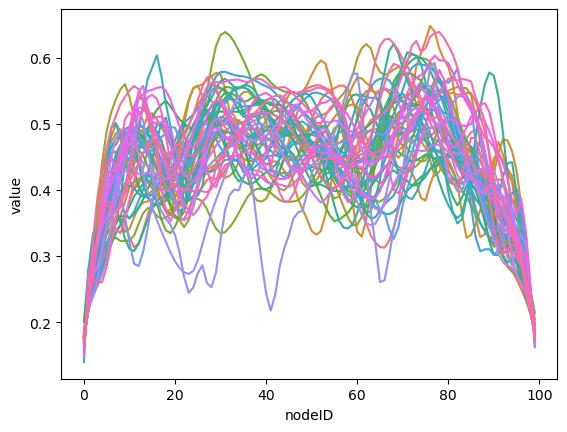

In [655]:
import seaborn as sns
import matplotlib.pyplot as plt

df_sel = df_subj_long.loc[
    (df_subj_long['tractID'] == 'Left Arcuate') &
    (df_subj_long['measure_type'] == 'fa')
].copy()


sns.lineplot(x=df_sel['nodeID'], y=df_sel['value'], hue=df_sel['subjectID'], legend=False)
plt.show()
